# 04 - Segmentation using GrabCut
```
Gambar -> resize 224x224 -> GrabCut (rect otomatis) -> mask masih kasar
       -> Morphology (opening + closing) -> mask bersih
       -> Contour terbesar -> mask objek -> gambar tersegmentasi
```

## 1. Import Library

In [1]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 6)
print("OpenCV version:", cv2.__version__)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenCV version: 4.13.0


## 2. Konfigurasi Path Dataset

In [ ]:
PROJECT_ROOT = Path("..").resolve()
folder_input = PROJECT_ROOT / "data" / "split"   #HARUSNYA PAKE CLAHE            
folder_output = PROJECT_ROOT / "data" / "segmented_grabcut"   

SPLITS = ["train", "val", "test"]
CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "biological"]

# Parameter pipeline
TARGET_SIZE = (224, 224)   
MARGIN = 15                
GRABCUT_ITER = 5           
KERNEL_SIZE = 5            

print("Folder input :", folder_input)
print("Folder output:", folder_output)
print("Input ada?   :", folder_input.exists())

for split in SPLITS:
    for nama_kelas in CLASSES:
        (folder_output / split / nama_kelas).mkdir(parents=True, exist_ok=True)

print("\nStruktur folder output siap dibuat di:", folder_output)

Folder input : C:\Users\User\Downloads\Waste Classification - PCD Project\data\split
Folder output: C:\Users\User\Downloads\Waste Classification - PCD Project\data\segmented_grabcut
Input ada?   : True

Struktur folder output siap dibuat di: C:\Users\User\Downloads\Waste Classification - PCD Project\data\segmented_grabcut


## 3. Fungsi GrabCut

In [3]:
def buat_rect_otomatis(width, height, margin=MARGIN):
    
    """Initial rectangle dengan margin dari tepi: (x, y, w, h)."""
    margin = int(min(margin, width // 2 - 1, height // 2 - 1))
    margin = max(margin, 1)
    rect = (margin, margin, width - 2 * margin, height - 2 * margin)
    return rect


def segmentasi_grabcut(gambar, target_size=TARGET_SIZE, margin=MARGIN,
                       iterasi=GRABCUT_ITER):

    # Resize ke ukuran target 
    gambar_resize = cv2.resize(gambar, target_size, interpolation=cv2.INTER_AREA)
    height, width = gambar_resize.shape[:2]

    # Inisialisasi mask & model background/foreground untuk GrabCut
    mask = np.zeros((height, width), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    rect = buat_rect_otomatis(width, height, margin)
    cv2.grabCut(gambar_resize, mask, rect, bgd_model, fgd_model,
                iterasi, cv2.GC_INIT_WITH_RECT)

    # GC_FGD(1) & GC_PR_FGD(3) dianggap foreground -> jadi 255
    mask_grabcut = np.where(
        (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0
    ).astype("uint8")
    return gambar_resize, mask_grabcut

## 4. Fungsi Morphological Processing

In [4]:
def bersihkan_mask(mask_grabcut, kernel_size=KERNEL_SIZE):
    """Opening (hapus noise) + Closing (tutup lubang) pada mask biner."""
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)
    )
    # Opening
    mask_open = cv2.morphologyEx(mask_grabcut, cv2.MORPH_OPEN, kernel)
    
    # Closing
    mask_bersih = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel)
    return mask_bersih

## 5. Fungsi Contour Extraction

In [5]:
def ambil_contour_terbesar(mask_bersih):
    """Buat mask hanya dari contour terbesar. Fallback ke mask asal bila kosong."""
    contours, _ = cv2.findContours(
        mask_bersih, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        
        return mask_bersih.copy()

    contour_terbesar = max(contours, key=cv2.contourArea)
    mask_objek = np.zeros_like(mask_bersih)
    cv2.drawContours(mask_objek, [contour_terbesar], -1, 255, thickness=cv2.FILLED)
    return mask_objek


def terapkan_mask(gambar_bgr, mask):
    """Terapkan mask biner ke gambar -> background jadi hitam."""
    mask_bin = (mask > 0).astype("uint8")
    gambar_segmentasi = cv2.bitwise_and(gambar_bgr, gambar_bgr, mask=mask_bin)
    return gambar_segmentasi

## 6. Pipeline

In [6]:
def pipeline_segmentasi(path_atau_gambar, target_size=TARGET_SIZE, margin=MARGIN,
                        iterasi=GRABCUT_ITER, kernel_size=KERNEL_SIZE):

    if isinstance(path_atau_gambar, (str, Path)):
        gambar = cv2.imread(str(path_atau_gambar))
        if gambar is None:
            raise ValueError(f"Gagal membaca gambar: {path_atau_gambar}")
    else:
        gambar = path_atau_gambar

    gambar_resize, mask_grabcut = segmentasi_grabcut(
        gambar, target_size, margin, iterasi
    )
    mask_bersih = bersihkan_mask(mask_grabcut, kernel_size)
    mask_objek = ambil_contour_terbesar(mask_bersih)
    gambar_segmentasi = terapkan_mask(gambar_resize, mask_objek)

    return {
        "original": gambar_resize,        # BGR
        "mask_grabcut": mask_grabcut,     # mask mentah
        "mask_bersih": mask_bersih,       # setelah morphology
        "mask_objek": mask_objek,         # contour terbesar
        "segmentasi": gambar_segmentasi,  # hasil akhir (BGR)
    }

## 7. Visualisasi  Hasil Segmentasi

In [7]:
def kumpulkan_semua_path(folder, splits=SPLITS, classes=CLASSES):
    
    ekstensi = {".jpg", ".jpeg", ".png", ".bmp"}
    daftar = []
    for split in splits:
        for nama_kelas in classes:
            folder_kelas = folder / split / nama_kelas
            if not folder_kelas.exists():
                continue
            for p in folder_kelas.iterdir():
                if p.suffix.lower() in ekstensi:
                    daftar.append((split, nama_kelas, p))
    return daftar


semua_path = kumpulkan_semua_path(folder_input)
print(f"Total gambar ditemukan di folder input: {len(semua_path)}")

Total gambar ditemukan di folder input: 7709


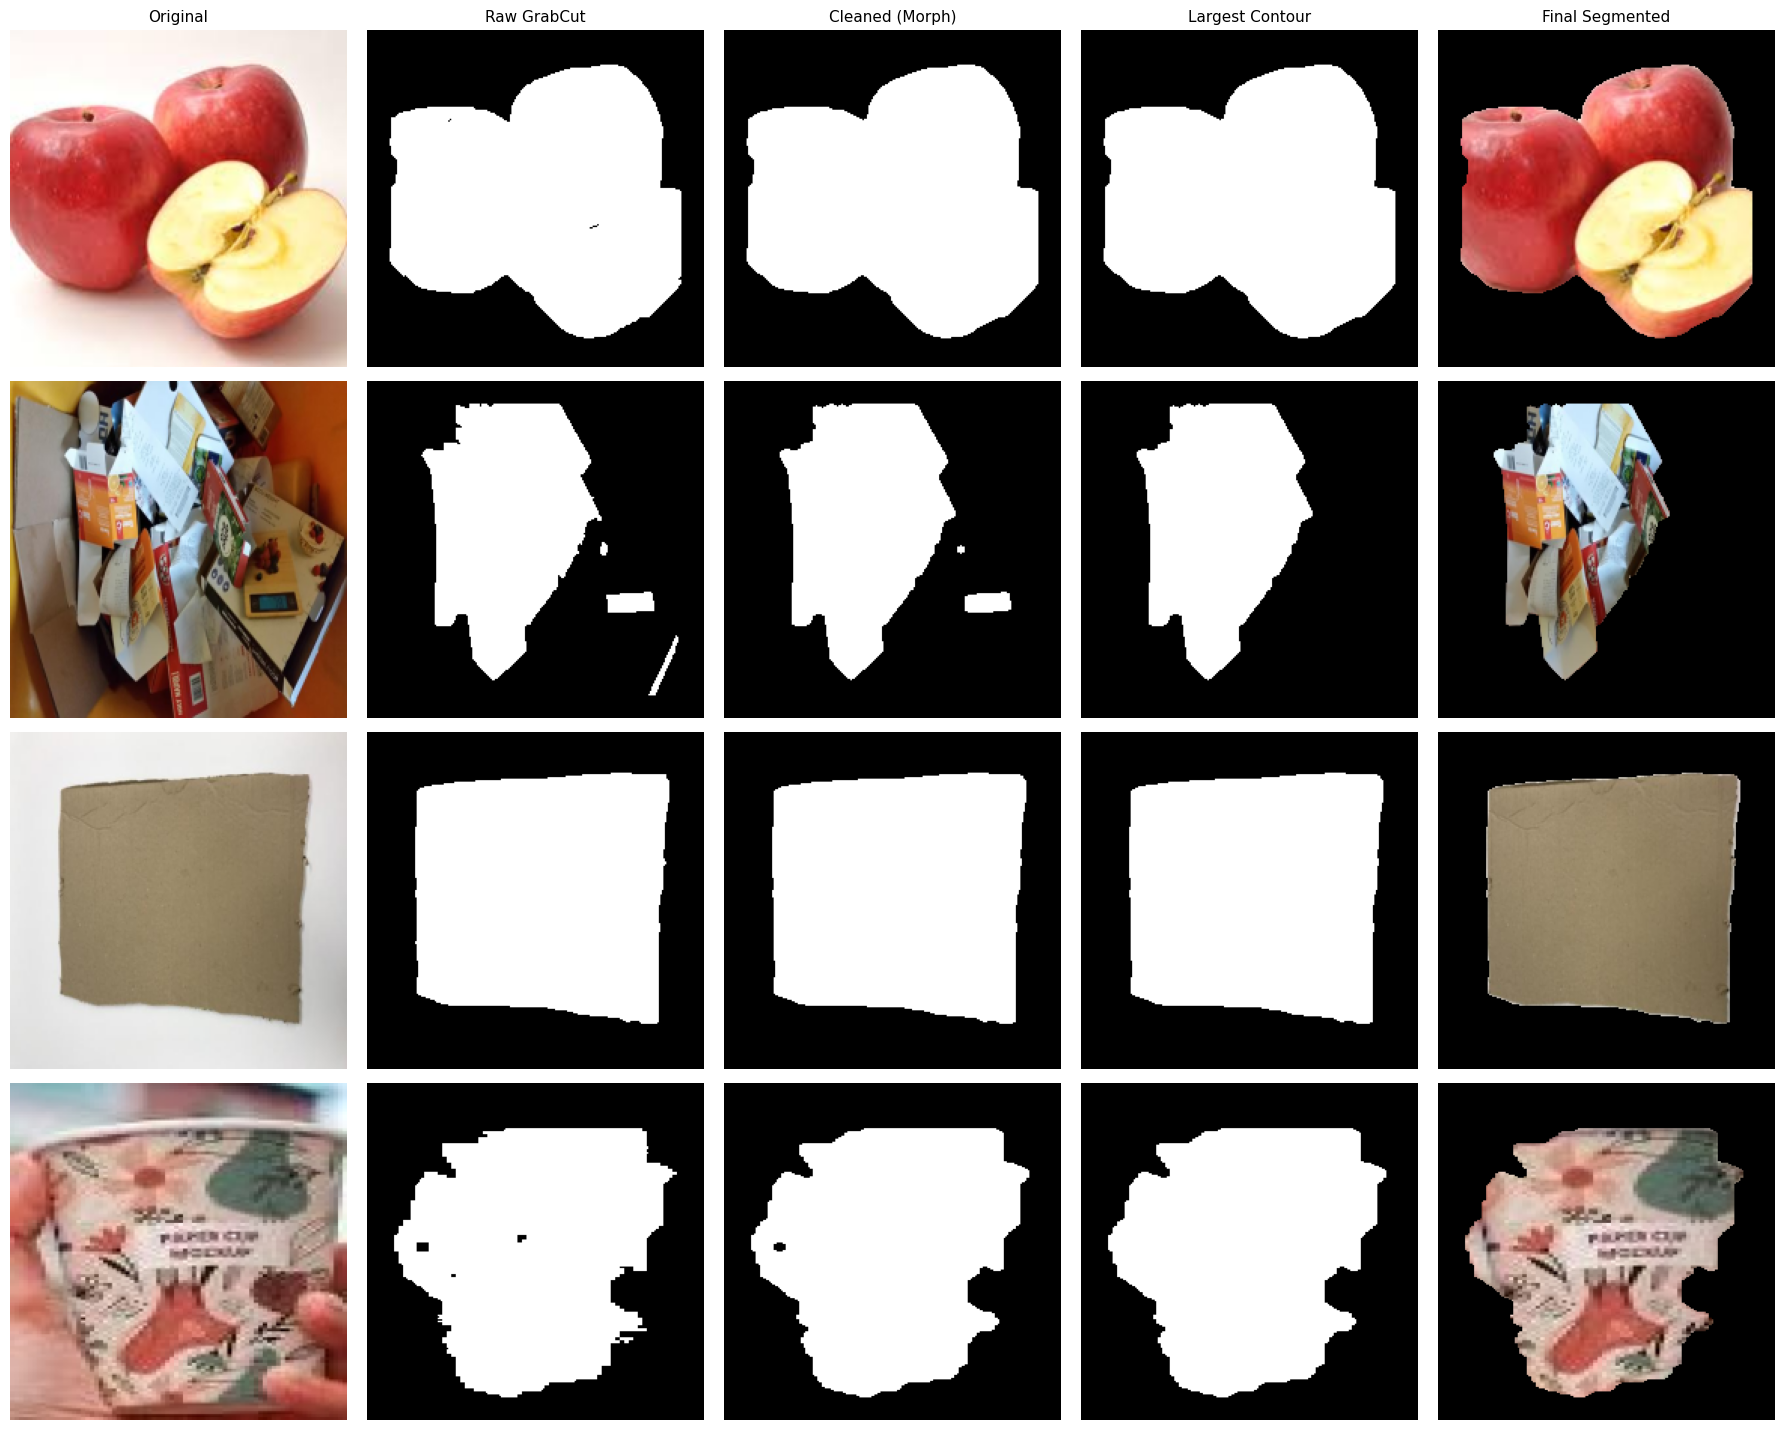

In [8]:
def tampilkan_contoh(daftar_path, jumlah=4):
   
    sample = random.sample(daftar_path, min(jumlah, len(daftar_path)))
    judul = ["Original", "Raw GrabCut", "Cleaned (Morph)",
             "Largest Contour", "Final Segmented"]

    fig, axes = plt.subplots(len(sample), 5, figsize=(18, 3.6 * len(sample)))
    if len(sample) == 1:
        axes = axes[np.newaxis, :]

    for i, (split, nama_kelas, path) in enumerate(sample):
        hasil = pipeline_segmentasi(path)
        gambar_list = [
            cv2.cvtColor(hasil["original"], cv2.COLOR_BGR2RGB),
            hasil["mask_grabcut"],
            hasil["mask_bersih"],
            hasil["mask_objek"],
            cv2.cvtColor(hasil["segmentasi"], cv2.COLOR_BGR2RGB),
        ]
        for j, (img, t) in enumerate(zip(gambar_list, judul)):
            ax = axes[i, j]
            if img.ndim == 2:
                ax.imshow(img, cmap="gray")
            else:
                ax.imshow(img)
            ax.axis("off")
            if i == 0:
                ax.set_title(t, fontsize=11)
            if j == 0:
                ax.set_ylabel(f"{nama_kelas}\n({split})", fontsize=9)
    plt.tight_layout()
    plt.show()


tampilkan_contoh(semua_path, jumlah=4)

## 8. Foreground Ratio (Helper)

`foreground_ratio` = jumlah piksel foreground / total piksel gambar. Ini untuk Matrix Evaluasi: nilai sangat kecil berarti objek nyaris
hilang (under-segmentation), dan nilai mendekati 1 berarti hampir seluruh
gambar dianggap objek (background tidak terbuang)

In [9]:
def hitung_foreground_ratio(mask):
    """Rasio piksel foreground terhadap total piksel."""
    total = mask.size
    foreground = int(np.count_nonzero(mask))
    return foreground / total if total else 0.0

## 9. Batch Processing 

In [10]:
# Catatan hasil batch
gambar_gagal = []                                  
records = []                                       
jumlah_berhasil = 0

daftar_proses = kumpulkan_semua_path(folder_input)

for split, nama_kelas, path_input in tqdm(daftar_proses, desc="Segmentasi GrabCut"):
    try:
        hasil = pipeline_segmentasi(path_input)
        gambar_segmentasi = hasil["segmentasi"]

        # Simpan dengan nama asli, paksa ekstensi .jpg
        nama_output = path_input.stem + ".jpg"
        path_output = folder_output / split / nama_kelas / nama_output
        ok = cv2.imwrite(str(path_output), gambar_segmentasi)
        if not ok:
            raise IOError("cv2.imwrite mengembalikan False")

        ratio = hitung_foreground_ratio(hasil["mask_objek"])
        records.append((split, nama_kelas, ratio))
        jumlah_berhasil += 1
    except Exception as e: 
        gambar_gagal.append((str(path_input), str(e)))

print(f"\nBerhasil diproses : {jumlah_berhasil}")
print(f"Gagal diproses    : {len(gambar_gagal)}")

Segmentasi GrabCut: 100%|██████████| 7709/7709 [1:14:18<00:00,  1.73it/s]


Berhasil diproses : 7709
Gagal diproses    : 0


In [11]:
if gambar_gagal:
    print(f"Total gagal: {len(gambar_gagal)}. Contoh file yang gagal:")
    for path, err in gambar_gagal[:10]:
        print(f"  - {path}  ->  {err}")
else:
    print("Tidak ada gambar yang gagal")

Tidak ada gambar yang gagal


## 10. Evaluasi Hasil Segmentasi

In [12]:
import collections

# 1. Jumlah hasil per split dan per kelas (
print("Jumlah gambar hasil segmentasi per split / kelas:\n")
hitungan = collections.defaultdict(dict)
for split in SPLITS:
    total_split = 0
    for nama_kelas in CLASSES:
        folder_kelas = folder_output / split / nama_kelas
        n = len(list(folder_kelas.glob("*.jpg"))) if folder_kelas.exists() else 0
        hitungan[split][nama_kelas] = n
        total_split += n
    baris = "  ".join(f"{k}={hitungan[split][k]}" for k in CLASSES)
    print(f"[{split:5s}] total={total_split:5d} | {baris}")

Jumlah gambar hasil segmentasi per split / kelas:

[train] total= 5396 | cardboard=988  glass=1215  metal=651  paper=935  plastic=1118  biological=489
[val  ] total= 1156 | cardboard=211  glass=260  metal=140  paper=201  plastic=239  biological=105
[test ] total= 1157 | cardboard=212  glass=261  metal=139  paper=200  plastic=240  biological=105


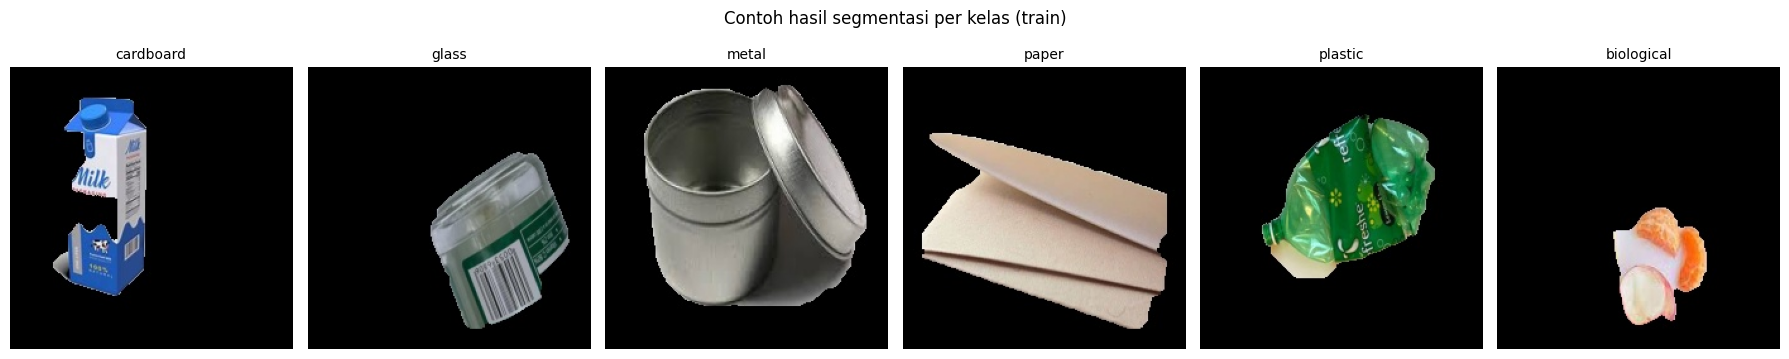

In [13]:
# 2. Sample hasil segmentasi dari setiap kelas 
fig, axes = plt.subplots(1, len(CLASSES), figsize=(3 * len(CLASSES), 3.5))
for ax, nama_kelas in zip(axes, CLASSES):
    folder_kelas = folder_output / "train" / nama_kelas
    files = list(folder_kelas.glob("*.jpg")) if folder_kelas.exists() else []
    if files:
        img = cv2.imread(str(random.choice(files)))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(nama_kelas, fontsize=10)
    ax.axis("off")
plt.suptitle("Contoh hasil segmentasi per kelas (train)", y=1.02)
plt.tight_layout()
plt.show()

Ringkasan statistik foreground_ratio:
  jumlah : 7709
  min    : 0.000
  max    : 0.730
  mean   : 0.301
  median : 0.301
  std    : 0.156


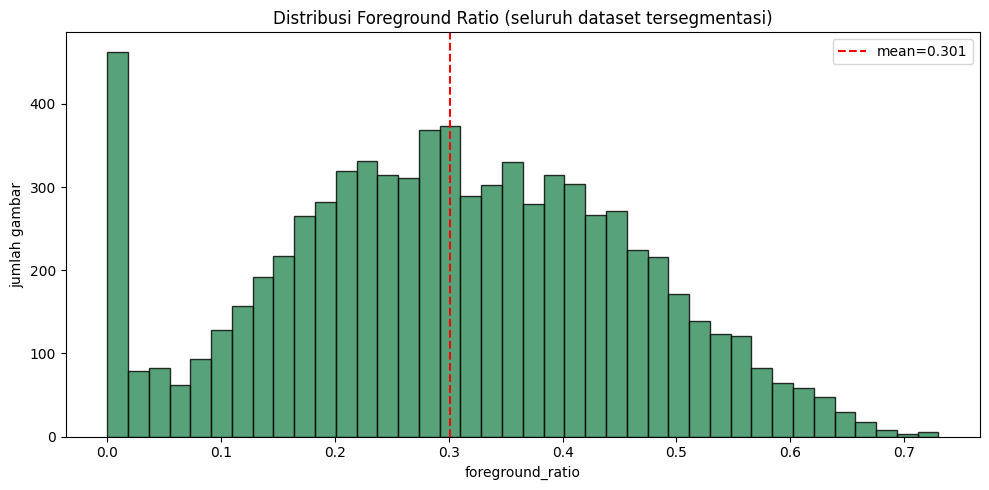

In [14]:
# 3. Distribusi foreground ratio
ratios = np.array([r for (_, _, r) in records], dtype=float)

if ratios.size:
    print("Ringkasan statistik foreground_ratio:")
    print(f"  jumlah : {ratios.size}")
    print(f"  min    : {ratios.min():.3f}")
    print(f"  max    : {ratios.max():.3f}")
    print(f"  mean   : {ratios.mean():.3f}")
    print(f"  median : {np.median(ratios):.3f}")
    print(f"  std    : {ratios.std():.3f}")

    plt.figure(figsize=(10, 5))
    plt.hist(ratios, bins=40, color="seagreen", edgecolor="black", alpha=0.8)
    plt.axvline(ratios.mean(), color="red", linestyle="--",
                label=f"mean={ratios.mean():.3f}")
    plt.title("Distribusi Foreground Ratio (seluruh dataset tersegmentasi)")
    plt.xlabel("foreground_ratio")
    plt.ylabel("jumlah gambar")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Belum ada record foreground ratio")

In [15]:
# Foreground ratio rata-rata per kelas (membantu deteksi kelas yang sulit disegmentasi)
import statistics

per_kelas = collections.defaultdict(list)
for split, nama_kelas, r in records:
    per_kelas[nama_kelas].append(r)

print("Rata-rata foreground_ratio per kelas:")
for nama_kelas in CLASSES:
    vals = per_kelas.get(nama_kelas, [])
    if vals:
        print(f"  {nama_kelas:10s}: mean={statistics.mean(vals):.3f}  n={len(vals)}")
    else:
        print(f"  {nama_kelas:10s}: (tidak ada data)")

Rata-rata foreground_ratio per kelas:
  cardboard : mean=0.330  n=1411
  glass     : mean=0.280  n=1736
  metal     : mean=0.321  n=930
  paper     : mean=0.310  n=1336
  plastic   : mean=0.287  n=1597
  biological: mean=0.290  n=699


## 11. Kesimpulan 

In [ ]:

print("Metode final     : GrabCut + Morphology (opening+closing) + Contour terbesar")
print(f"Folder input     : {folder_input}  (READ-ONLY, tidak diubah)")
print(f"Folder output    : {folder_output}")
print(f"Ukuran citra     : {TARGET_SIZE[0]}x{TARGET_SIZE[1]}")
print(f"Parameter        : margin={MARGIN}, grabcut_iter={GRABCUT_ITER}, "
      f"kernel_size={KERNEL_SIZE}")
print(f"Berhasil diproses: {jumlah_berhasil} gambar")
print(f"Gagal diproses   : {len(gambar_gagal)} gambar")  

Metode final     : GrabCut + Morphology (opening+closing) + Contour terbesar
Folder input     : C:\Users\User\Downloads\Waste Classification - PCD Project\data\split  (READ-ONLY, tidak diubah)
Folder output    : C:\Users\User\Downloads\Waste Classification - PCD Project\data\segmented_grabcut
Ukuran citra     : 224x224
Parameter        : margin=15, grabcut_iter=5, kernel_size=5
Berhasil diproses: 7709 gambar
Gagal diproses   : 0 gambar


min nya ada yg 0.00, coba nanti cek dulu gambar nya gimana